In [ ]:
import random
import copy
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_num_threads(max(1, torch.get_num_threads() - 1))

print("PyTorch version:", torch.__version__)
print("CPU threads:", torch.get_num_threads())

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

DATA_FILE = "../data/idm_pt.tsv"
MODELS_DIR = "../models/nb2/"
RESULTS_DIR = "../results/nb2/"

# ------------------------------------------------------------
# Dataset configuration
# ------------------------------------------------------------

BSM_FEATURES = ["mH", "mA", "mHp", "l2", "l345"]

# These are the columns used by ML.
TARGET_COLUMNS = ["Tcrit", "Tnuc", "log_alpha", "log_beta/H"]

# Original physical quantities.
PHYSICAL_TARGET_COLUMNS = ["Tcrit", "Tnuc", "alpha", "beta/H"]


# Number of outputs
N_FEATURES = len(BSM_FEATURES)
N_TARGETS = len(TARGET_COLUMNS)


# ------------------------------------------------------------
# Train / validation / test fractions
# ------------------------------------------------------------

TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15

# Since validation is carved out of the 85% development set:
VALIDATION_SIZE_INSIDE_DEV = VALIDATION_SIZE / (1.0 - TEST_SIZE)

print("Number of input features:", N_FEATURES)
print("Number of targets:", N_TARGETS)

PyTorch version: 2.14.0+cpu
CPU threads: 3
Number of input features: 5
Number of targets: 4


In [2]:
# ============================================================
# 2. Load and validate dataset
# ============================================================

df = pd.read_csv(DATA_FILE, sep="\t")
df_clean = df.copy()
df_clean["Tcrit"] = df_clean["Tcrit"].mask(df_clean["Tcrit"] == -999, df_clean["Tnuc"])
df_clean = df_clean[df_clean["beta/H"] != -999]
df_clean["log_alpha"] = np.log10(df_clean["alpha"])
df_clean["log_beta/H"] = np.log10(df_clean["beta/H"])

# ------------------------------------------------------------
# Select one-step FOPT sample
# ------------------------------------------------------------

df_ml = df_clean[df_clean["transition_pattern"] == 'oh1'].copy()
print(df_ml.shape)
df_ml[BSM_FEATURES + TARGET_COLUMNS].describe().T

(50297, 20)


,count,mean,std,min,25%,50%,75%,max
mH,50297.0,183.547872,50.824493,46.266962,149.840121,195.517634,226.230758,249.999661
mA,50297.0,318.390926,81.748667,46.398863,261.812989,319.986041,380.676768,499.907029
mHp,50297.0,336.232772,82.778338,70.409150,280.809764,341.964620,398.592772,530.183763
l2,50297.0,1.919572,1.097292,0.000112,0.986682,1.906370,2.840399,4.161707
l345,50297.0,1.047533,0.604068,0.000030,0.554487,1.012635,1.506306,2.713783
Tcrit,50297.0,116.654636,15.814025,71.638750,106.102871,118.417725,127.767578,156.720831
Tnuc,50297.0,113.359869,20.384383,37.885160,102.171051,117.314253,127.552613,156.713495
log_alpha,50297.0,-2.379646,0.730958,-4.317576,-2.814510,-2.296829,-1.894980,-0.146363
log_beta/H,50297.0,4.515161,1.016236,0.666147,3.765377,4.432380,5.266219,13.749588


In [3]:
# ============================================================
# 3. Development / validation / test split
# ============================================================

dev_df, test_df = train_test_split(df_ml, test_size=TEST_SIZE, random_state=SEED)

train_df, validation_df = train_test_split(dev_df, test_size=VALIDATION_SIZE_INSIDE_DEV, random_state=SEED)

print("Full dataset: :", df_ml.shape)
print("Development:  :", dev_df.shape)
print("Training:     :", train_df.shape)
print("Validation:   :", validation_df.shape)
print("Test:         :", test_df.shape)

Full dataset: : (50297, 20)
Development:  : (42752, 20)
Training:     : (35207, 20)
Validation:   : (7545, 20)
Test:         : (7545, 20)


In [4]:
# ============================================================
# 4. Prepare ML arrays
# ============================================================

X_train = train_df[BSM_FEATURES].to_numpy(dtype=np.float32)
X_validation = validation_df[BSM_FEATURES].to_numpy(dtype=np.float32)
X_test = test_df[BSM_FEATURES].to_numpy(dtype=np.float32)

y_train = train_df[TARGET_COLUMNS].to_numpy(dtype=np.float32)
y_validation = validation_df[TARGET_COLUMNS].to_numpy(dtype=np.float32)
y_test = test_df[TARGET_COLUMNS].to_numpy(dtype=np.float32)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_validation.shape)
print("y_validation:", y_validation.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (35207, 5)
y_train: (35207, 4)
X_validation: (7545, 5)
y_validation: (7545, 4)
X_test: (7545, 5)
y_test: (7545, 4)


In [5]:
# ============================================================
# 5. Standardize BSM input features
# ============================================================

feature_scaler = StandardScaler()

X_train_scaled = feature_scaler.fit_transform(X_train)
X_validation_scaled = feature_scaler.transform(X_validation)
X_test_scaled = feature_scaler.transform(X_test)

In [6]:
# ============================================================
# 6. Evaluation utilities
# ============================================================

def evaluate_predictions(y_true, y_pred, target_names):
    """
    Evaluate each target independently.
    """
    rows = []

    for i, target in enumerate(target_names):

        rmse = root_mean_squared_error(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2 = r2_score(y_true[:, i], y_pred[:, i])

        rows.append({"target": target, "RMSE": rmse, "MAE": mae, "R2": r2})

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# Convert transformed targets back to physical variables
# ------------------------------------------------------------

def to_physical_targets(y_transformed):

    result = np.empty_like(y_transformed)

    result[:, 0] = y_transformed[:, 0]
    result[:, 1] = y_transformed[:, 1]
    result[:, 2] = 10**y_transformed[:, 2]
    result[:, 3] = 10**y_transformed[:, 3]

    return result


In [7]:
# ============================================================
# 7. Linear regression baseline
# ============================================================

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_validation_pred = (linear_model.predict(X_validation_scaled))
linear_test_pred = (linear_model.predict(X_test_scaled))

# ------------------------------------------------------------
# Validation performance
# ------------------------------------------------------------

linear_validation_results = evaluate_predictions(y_validation, linear_validation_pred, TARGET_COLUMNS)
linear_validation_results

,target,RMSE,MAE,R2
0,Tcrit,4.937346,3.881155,0.903500
1,Tnuc,7.814985,5.935680,0.853697
2,log_alpha,0.229050,0.172478,0.902968
3,log_beta/H,0.368967,0.278046,0.869736


In [8]:
# ============================================================
# 8. Histogram Gradient Boosting
# ============================================================

gradient_boosting_base = (
    HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=30,
        l2_regularization=1.0,
        early_stopping=False,
        random_state=SEED,
    )
)

gradient_boosting_model = MultiOutputRegressor(gradient_boosting_base, n_jobs=-2)
gradient_boosting_model.fit(X_train, y_train)

gradient_validation_pred = (gradient_boosting_model.predict(X_validation))
gradient_test_pred = (gradient_boosting_model.predict(X_test))

In [9]:
# ------------------------------------------------------------
# Validation performance
# ------------------------------------------------------------

gradient_validation_results = evaluate_predictions(y_validation, gradient_validation_pred, TARGET_COLUMNS)
gradient_validation_results

,target,RMSE,MAE,R2
0,Tcrit,1.238780,0.974326,0.993925
1,Tnuc,2.204011,1.505137,0.988363
2,log_alpha,0.103464,0.078348,0.980201
3,log_beta/H,0.154186,0.112944,0.977252


In [10]:
# ============================================================
# 9. Scale targets for neural network
# ============================================================

target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(y_train)
y_validation_scaled = target_scaler.transform(y_validation)
y_test_scaled = target_scaler.transform(y_test)

In [11]:
# ============================================================
# 10. Define neural network
# ============================================================

class PTRegressor(nn.Module):

    def __init__(self, n_inputs, n_outputs):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(n_inputs, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, n_outputs),
        )

    def forward(self, x):
        return self.network(x)

In [12]:
# ============================================================
# 11. PyTorch datasets
# ============================================================

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)

X_validation_tensor = torch.tensor(X_validation_scaled, dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation_scaled, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

In [13]:
# ============================================================
# 12. Train neural network
# ============================================================

mlp_model = PTRegressor(n_inputs=N_FEATURES, n_outputs=N_TARGETS).to(DEVICE)

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-5)

MAX_EPOCHS = 300
PATIENCE = 25

best_validation_loss = np.inf
best_state = None
epochs_without_improvement = 0

training_history = []

for epoch in range(1, MAX_EPOCHS + 1):

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    mlp_model.train()

    batch_losses = []

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        prediction = mlp_model(X_batch)

        loss = loss_function(prediction, y_batch)

        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())


    mean_train_loss = np.mean(batch_losses)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    mlp_model.eval()

    with torch.no_grad():

        validation_prediction = (mlp_model(X_validation_tensor.to(DEVICE)))

        validation_loss = (loss_function(validation_prediction, y_validation_tensor.to(DEVICE)).item())

    training_history.append({
        "epoch": epoch,
        "train_loss": mean_train_loss,
        "validation_loss": validation_loss,
    })

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss

        best_state = copy.deepcopy(mlp_model.state_dict())

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:

        print(
            f"Epoch {epoch:3d} | "
            f"train MSE = {mean_train_loss:.6f} | "
            f"validation MSE = {validation_loss:.6f}"
        )


    if epochs_without_improvement >= PATIENCE:

        print(f"\nEarly stopping at epoch {epoch}")
        break


# Restore best model
mlp_model.load_state_dict(best_state)

Epoch   1 | train MSE = 0.499989 | validation MSE = 0.088580
Epoch  10 | train MSE = 0.005171 | validation MSE = 0.004305
Epoch  20 | train MSE = 0.003224 | validation MSE = 0.002601
Epoch  30 | train MSE = 0.002778 | validation MSE = 0.002186
Epoch  40 | train MSE = 0.002515 | validation MSE = 0.002142
Epoch  50 | train MSE = 0.002473 | validation MSE = 0.001721
Epoch  60 | train MSE = 0.002329 | validation MSE = 0.001916
Epoch  70 | train MSE = 0.002159 | validation MSE = 0.001578
Epoch  80 | train MSE = 0.002201 | validation MSE = 0.001540
Epoch  90 | train MSE = 0.002098 | validation MSE = 0.001612
Epoch 100 | train MSE = 0.002065 | validation MSE = 0.001479
Epoch 110 | train MSE = 0.002049 | validation MSE = 0.001410
Epoch 120 | train MSE = 0.001969 | validation MSE = 0.001409
Epoch 130 | train MSE = 0.001970 | validation MSE = 0.001903
Epoch 140 | train MSE = 0.001918 | validation MSE = 0.001409
Epoch 150 | train MSE = 0.001899 | validation MSE = 0.001392
Epoch 160 | train MSE = 

<All keys matched successfully>

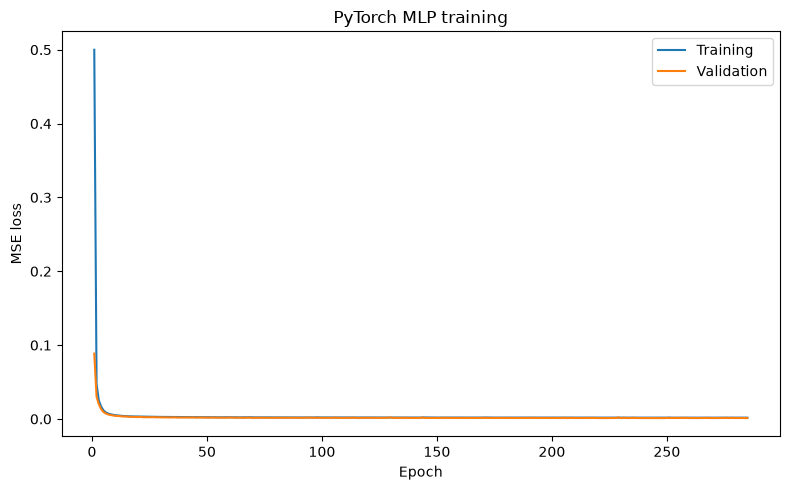

In [14]:
# ============================================================
# 13. Neural-network training history
# ============================================================

history = pd.DataFrame(training_history)

plt.figure(figsize=(8, 5))

plt.plot(history["epoch"], history["train_loss"], label="Training")

plt.plot(history["epoch"], history["validation_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("PyTorch MLP training")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 14. Neural-network predictions
# ============================================================

mlp_model.eval()

with torch.no_grad():

    mlp_validation_scaled = (mlp_model(X_validation_tensor.to(DEVICE)).cpu().numpy())
    mlp_test_scaled = (mlp_model(X_test_tensor.to(DEVICE)).cpu().numpy())


# Back to original target scaling
mlp_validation_pred = (target_scaler.inverse_transform(mlp_validation_scaled))
mlp_test_pred = (target_scaler.inverse_transform(mlp_test_scaled))

In [16]:
# ============================================================
# 15. Neural-network validation performance
# ============================================================

mlp_validation_results = evaluate_predictions(y_validation, mlp_validation_pred, TARGET_COLUMNS)
mlp_validation_results

,target,RMSE,MAE,R2
0,Tcrit,0.195878,0.148547,0.999848
1,Tnuc,0.428614,0.236676,0.999560
2,log_alpha,0.017754,0.009815,0.999417
3,log_beta/H,0.061205,0.024096,0.996416


In [17]:
# ============================================================
# 16. Validation comparison
# ============================================================

validation_predictions = {
    "Linear regression":
        linear_validation_pred,

    "Gradient boosting":
        gradient_validation_pred,

    "Neural network":
        mlp_validation_pred,
}

validation_results = []

for model_name, predictions in (validation_predictions.items()):

    result = evaluate_predictions(y_validation, predictions, TARGET_COLUMNS)
    result.insert(0, "model", model_name)
    validation_results.append(result)

validation_comparison = pd.concat(validation_results, ignore_index=True)
validation_comparison

,model,target,RMSE,MAE,R2
0,Linear regression,Tcrit,4.937346,3.881155,0.903500
1,Linear regression,Tnuc,7.814985,5.935680,0.853697
2,Linear regression,log_alpha,0.229050,0.172478,0.902968
3,Linear regression,log_beta/H,0.368967,0.278046,0.869736
4,Gradient boosting,Tcrit,1.238780,0.974326,0.993925
5,Gradient boosting,Tnuc,2.204011,1.505137,0.988363
6,Gradient boosting,log_alpha,0.103464,0.078348,0.980201
7,Gradient boosting,log_beta/H,0.154186,0.112944,0.977252
8,Neural network,Tcrit,0.195878,0.148547,0.999848
9,Neural network,Tnuc,0.428614,0.236676,0.999560


In [18]:
# ============================================================
# 17. Prediction plots
# ============================================================

def plot_predictions(y_true, y_pred, target_names, model_name):

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))

    for ax, i in zip(axes.ravel(), range(len(target_names))):

        ax.scatter(y_true[:, i], y_pred[:, i], s=8, alpha=0.35)

        minimum = min(y_true[:, i].min(), y_pred[:, i].min())
        maximum = max(y_true[:, i].max(), y_pred[:, i].max())

        ax.plot([minimum, maximum], [minimum, maximum], linestyle="--")

        ax.set_xlabel(f"True {target_names[i]}")
        ax.set_ylabel(f"Predicted {target_names[i]}")

        ax.set_title(f"{model_name}: {target_names[i]}")

    plt.tight_layout()
    plt.show()

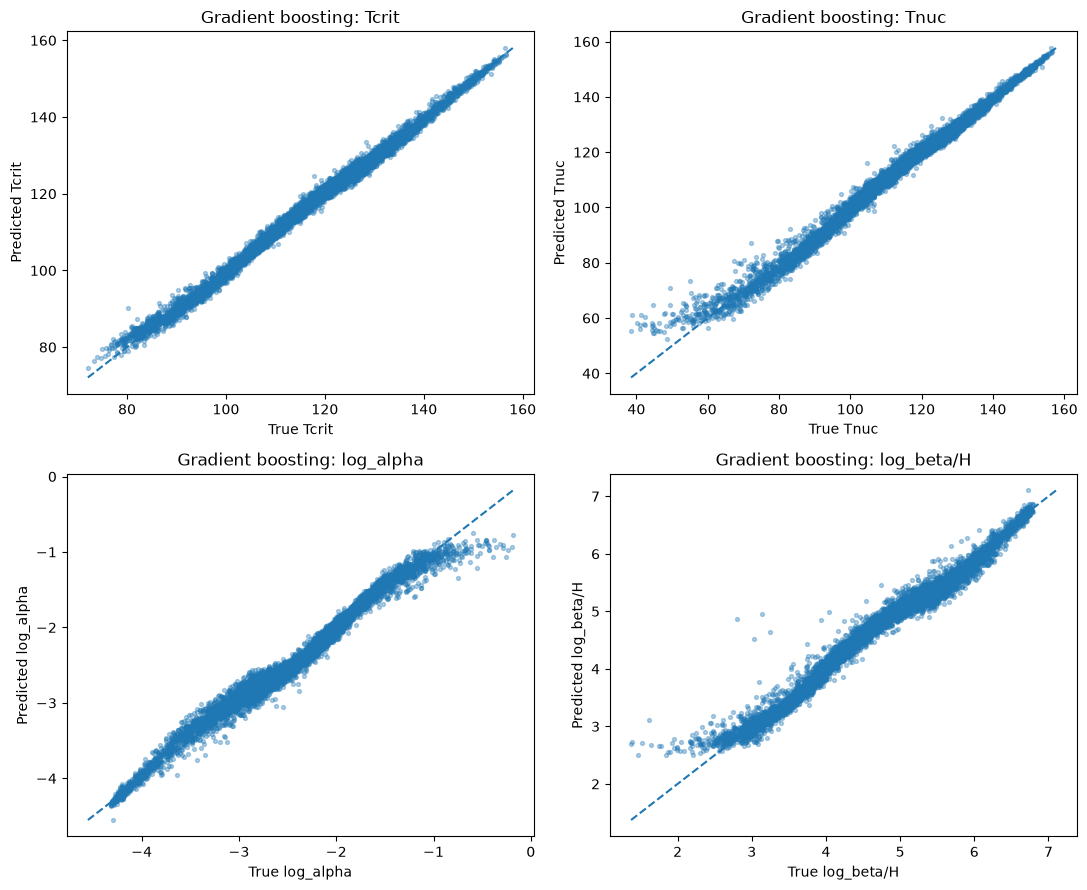

In [19]:
plot_predictions(
    y_validation,
    gradient_validation_pred,
    TARGET_COLUMNS,
    "Gradient boosting",
)

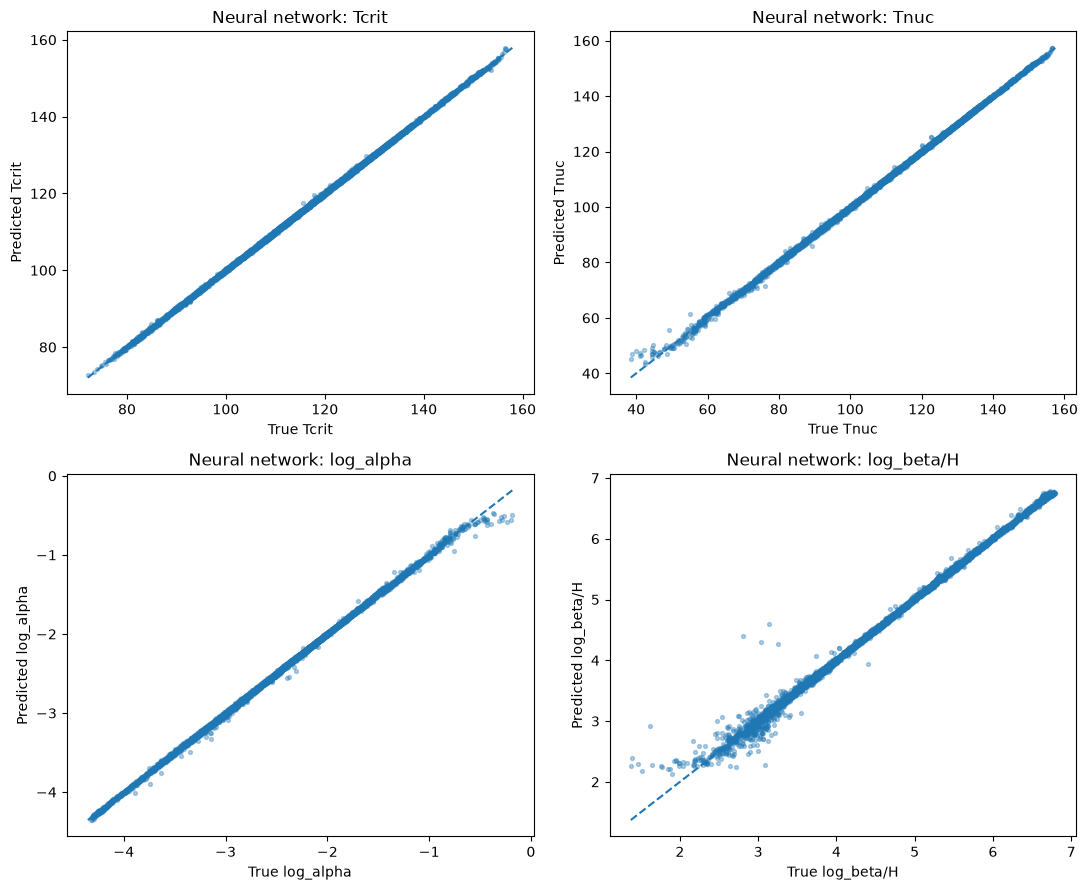

In [20]:
plot_predictions(
    y_validation,
    mlp_validation_pred,
    TARGET_COLUMNS,
    "Neural network",
)

In [21]:
# ============================================================
# 18. Permutation feature importance
# ============================================================

permutation_tables = []

for target_index, target_name in enumerate(TARGET_COLUMNS):

    estimator = (gradient_boosting_model.estimators_[target_index])

    importance = permutation_importance(
        estimator,
        X_validation,
        y_validation[:, target_index],
        scoring="neg_root_mean_squared_error",
        n_repeats=10,
        random_state=SEED,
        n_jobs=-2,
    )

    table = pd.DataFrame({
        "feature": BSM_FEATURES,
        "importance_mean": (importance.importances_mean),
        "importance_std": (importance.importances_std),
    })

    table["target"] = target_name
    permutation_tables.append(table)

permutation_importance_df = pd.concat(permutation_tables, ignore_index=True)
permutation_importance_df.sort_values(["target", "importance_mean"], ascending=[True, False])

/home/kethe/AI_projects/higgs_ml/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,feature,importance_mean,importance_std,target
2,mHp,18.451337,0.101247,Tcrit
4,l345,12.561768,0.104418,Tcrit
0,mH,10.702342,0.062170,Tcrit
1,mA,8.851009,0.053413,Tcrit
3,l2,4.423829,0.039848,Tcrit
7,mHp,24.251536,0.140101,Tnuc
9,l345,19.648105,0.168868,Tnuc
5,mH,16.578965,0.093826,Tnuc
6,mA,12.473189,0.089138,Tnuc
8,l2,4.713950,0.043020,Tnuc


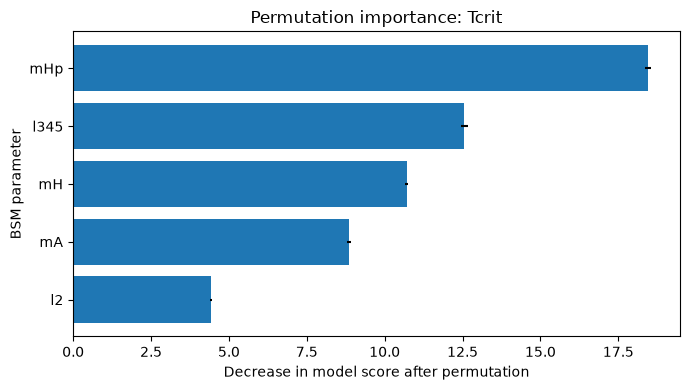

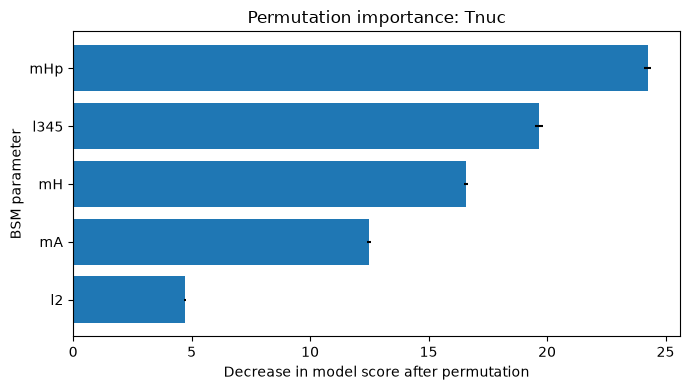

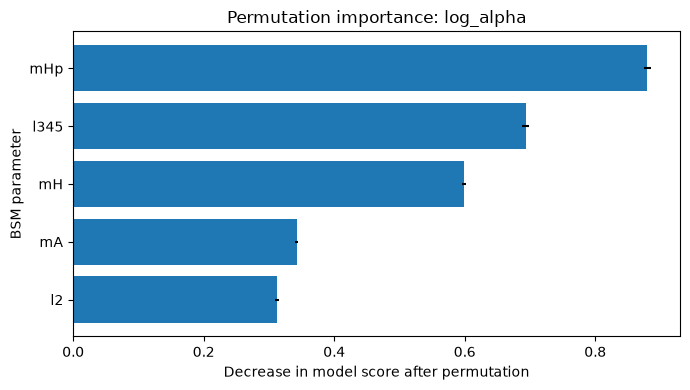

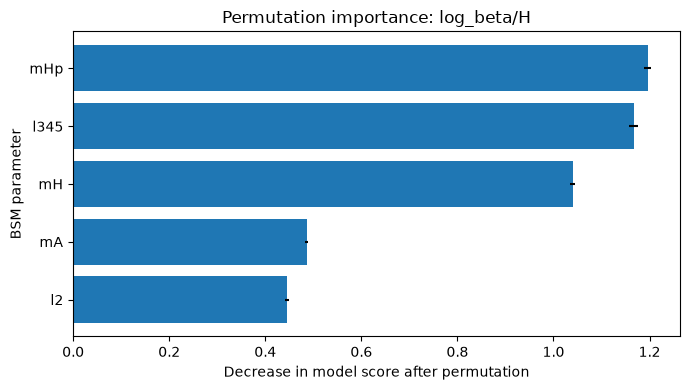

In [22]:
for target in TARGET_COLUMNS:

    subset = (permutation_importance_df[permutation_importance_df["target"] == target]
        .sort_values("importance_mean")
    )

    plt.figure(figsize=(7, 4))
    plt.barh(subset["feature"], subset["importance_mean"], xerr=subset["importance_std"])


    plt.xlabel("Decrease in model score after permutation" )
    plt.ylabel("BSM parameter")

    plt.title(f"Permutation importance: {target}")

    plt.tight_layout()
    plt.show()

In [23]:
# ============================================================
# 19. Final test evaluation
# ============================================================

test_predictions = {
    "Linear regression":
        linear_test_pred,

    "Gradient boosting":
        gradient_test_pred,

    "Neural network":
        mlp_test_pred,
}

test_results = []

for model_name, predictions in (test_predictions.items()):

    result = evaluate_predictions(y_test, predictions, TARGET_COLUMNS)
    result.insert(0, "model", model_name)
    test_results.append(result)

test_comparison = pd.concat(test_results, ignore_index=True)
test_comparison

,model,target,RMSE,MAE,R2
0,Linear regression,Tcrit,5.009631,3.906038,0.897891
1,Linear regression,Tnuc,8.022371,6.001245,0.843860
2,Linear regression,log_alpha,0.234527,0.174649,0.895472
3,Linear regression,log_beta/H,0.373204,0.281049,0.862889
4,Gradient boosting,Tcrit,1.239068,0.965290,0.993753
5,Gradient boosting,Tnuc,2.227798,1.473282,0.987959
6,Gradient boosting,log_alpha,0.105883,0.079763,0.978694
7,Gradient boosting,log_beta/H,0.151511,0.111664,0.977402
8,Neural network,Tcrit,0.208330,0.152268,0.999823
9,Neural network,Tnuc,0.448019,0.238228,0.999513


In [24]:
# ============================================================
# 20. Save results
# ============================================================

validation_comparison.to_csv(RESULTS_DIR + "validation_results.tsv", sep="\t", index=False)
test_comparison.to_csv(RESULTS_DIR + "test_results.tsv", sep="\t", index=False)

permutation_importance_df.to_csv(RESULTS_DIR + "permutation_importance.tsv", sep="\t", index=False)

history.to_csv(RESULTS_DIR + "mlp_training_history.tsv", sep="\t", index=False)

In [25]:
# ============================================================
# 21. Save trained models
# ============================================================

joblib.dump(feature_scaler, MODELS_DIR + "feature_scaler.pkl")
joblib.dump(target_scaler, MODELS_DIR + "target_scaler.pkl")

joblib.dump(linear_model, MODELS_DIR + "linear_regression.pkl")
joblib.dump(gradient_boosting_model, MODELS_DIR + "gradient_boosting.pkl")

torch.save(mlp_model.state_dict(), MODELS_DIR + "mlp_regressor.pt")